In [1]:
from google.colab import files
uploaded = files.upload()

Saving actual.csv to actual.csv
Saving data_set_ALL_AML_independent.csv to data_set_ALL_AML_independent.csv
Saving data_set_ALL_AML_train.csv to data_set_ALL_AML_train.csv


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [3]:
train = pd.read_csv('data_set_ALL_AML_train.csv')
test = pd.read_csv('data_set_ALL_AML_independent.csv')
actual = pd.read_csv('actual.csv')

In [4]:
train.head()

,Gene Description,Gene Accession Number,1,call,2,call.1,3,call.2,4,call.3,...,29,call.33,30,call.34,31,call.35,32,call.36,33,call.37
0,AFFX-BioB-5_at (endogenous control),AFFX-BioB-5_at,-214,A,-139,A,-76,A,-135,A,...,15,A,-318,A,-32,A,-124,A,-135,A
1,AFFX-BioB-M_at (endogenous control),AFFX-BioB-M_at,-153,A,-73,A,-49,A,-114,A,...,-114,A,-192,A,-49,A,-79,A,-186,A
2,AFFX-BioB-3_at (endogenous control),AFFX-BioB-3_at,-58,A,-1,A,-307,A,265,A,...,2,A,-95,A,49,A,-37,A,-70,A
3,AFFX-BioC-5_at (endogenous control),AFFX-BioC-5_at,88,A,283,A,309,A,12,A,...,193,A,312,A,230,P,330,A,337,A
4,AFFX-BioC-3_at (endogenous control),AFFX-BioC-3_at,-295,A,-264,A,-376,A,-419,A,...,-51,A,-139,A,-367,A,-188,A,-407,A


In [5]:
train.shape

(7129, 78)

In [6]:
test.shape

(7129, 70)

In [7]:
actual.head()

,patient,cancer
0,1,ALL
1,2,ALL
2,3,ALL
3,4,ALL
4,5,ALL


In [8]:
actual.shape

(72, 2)

In [9]:
train = pd.read_csv('data_set_ALL_AML_train.csv')

In [10]:
test = pd.read_csv('data_set_ALL_AML_independent.csv')
actual = pd.read_csv('actual.csv')

In [11]:
train = train.loc[:, ~train.columns.str.contains('call')]
test = test.loc[:, ~test.columns.str.contains('call')]

In [13]:
train.head()

,Gene Description,Gene Accession Number,1,2,3,4,5,6,7,8,...,35,36,37,38,28,29,30,31,32,33
0,AFFX-BioB-5_at (endogenous control),AFFX-BioB-5_at,-214,-139,-76,-135,-106,-138,-72,-413,...,7,-213,-25,-72,-4,15,-318,-32,-124,-135
1,AFFX-BioB-M_at (endogenous control),AFFX-BioB-M_at,-153,-73,-49,-114,-125,-85,-144,-260,...,-100,-252,-20,-139,-116,-114,-192,-49,-79,-186
2,AFFX-BioB-3_at (endogenous control),AFFX-BioB-3_at,-58,-1,-307,265,-76,215,238,7,...,-57,136,124,-1,-125,2,-95,49,-37,-70
3,AFFX-BioC-5_at (endogenous control),AFFX-BioC-5_at,88,283,309,12,168,71,55,-2,...,132,318,325,392,241,193,312,230,330,337
4,AFFX-BioC-3_at (endogenous control),AFFX-BioC-3_at,-295,-264,-376,-419,-230,-272,-399,-541,...,-377,-209,-396,-324,-191,-51,-139,-367,-188,-407


In [14]:
train = train.set_index('Gene Description')

In [15]:
train = train.T

In [16]:
test = test.set_index('Gene Description').T

In [17]:
train.shape

(39, 7129)

In [18]:
test.shape

(35, 7129)

In [19]:
train.head()

Gene Description,AFFX-BioB-5_at (endogenous control),AFFX-BioB-M_at (endogenous control),AFFX-BioB-3_at (endogenous control),AFFX-BioC-5_at (endogenous control),AFFX-BioC-3_at (endogenous control),AFFX-BioDn-5_at (endogenous control),AFFX-BioDn-3_at (endogenous control),AFFX-CreX-5_at (endogenous control),AFFX-CreX-3_at (endogenous control),AFFX-BioB-5_st (endogenous control),...,Transcription factor Stat5b (stat5b) mRNA,Breast epithelial antigen BA46 mRNA,GB DEF = Calcium/calmodulin-dependent protein kinase II delta E mRNA; partial cds,TUBULIN ALPHA-4 CHAIN,CYP4B1 Cytochrome P450; subfamily IVB; polypeptide 1,PTGER3 Prostaglandin E receptor 3 (subtype EP3) {alternative products},HMG2 High-mobility group (nonhistone chromosomal) protein 2,RB1 Retinoblastoma 1 (including osteosarcoma),GB DEF = Glycophorin Sta (type A) exons 3 and 4; partial,GB DEF = mRNA (clone 1A7)
Gene Accession Number,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
1,-214,-153,-58,88,-295,-558,199,-176,252,206,...,185,511,-125,389,-37,793,329,36,191,-37
2,-139,-73,-1,283,-264,-400,-330,-168,101,74,...,169,837,-36,442,-17,782,295,11,76,-14
3,-76,-49,-307,309,-376,-650,33,-367,206,-215,...,315,1199,33,168,52,1138,777,41,228,-41
4,-135,-114,265,12,-419,-585,158,-253,49,31,...,240,835,218,174,-110,627,170,-50,126,-91


In [20]:
test.head()

Gene Description,AFFX-BioB-5_at (endogenous control),AFFX-BioB-M_at (endogenous control),AFFX-BioB-3_at (endogenous control),AFFX-BioC-5_at (endogenous control),AFFX-BioC-3_at (endogenous control),AFFX-BioDn-5_at (endogenous control),AFFX-BioDn-3_at (endogenous control),AFFX-CreX-5_at (endogenous control),AFFX-CreX-3_at (endogenous control),AFFX-BioB-5_st (endogenous control),...,Transcription factor Stat5b (stat5b) mRNA,Breast epithelial antigen BA46 mRNA,GB DEF = Calcium/calmodulin-dependent protein kinase II delta E mRNA; partial cds,TUBULIN ALPHA-4 CHAIN,CYP4B1 Cytochrome P450; subfamily IVB; polypeptide 1,PTGER3 Prostaglandin E receptor 3 (subtype EP3) {alternative products},HMG2 High-mobility group (nonhistone chromosomal) protein 2,RB1 Retinoblastoma 1 (including osteosarcoma),GB DEF = Glycophorin Sta (type A) exons 3 and 4; partial,GB DEF = mRNA (clone 1A7)
Gene Accession Number,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
39,-342,-200,41,328,-224,-427,-656,-292,137,-144,...,277,1023,67,214,-135,1074,475,48,168,-70
40,-87,-248,262,295,-226,-493,367,-452,194,162,...,83,529,-295,352,-67,67,263,-33,-33,-21
42,22,-153,17,276,-211,-250,55,-141,0,500,...,413,399,16,558,24,893,297,6,1971,-42
47,-243,-218,-163,182,-289,-268,-285,-172,52,-134,...,174,277,6,81,2,722,170,0,510,-73


In [21]:
actual.shape

(72, 2)

In [22]:
actual['cancer'].value_counts()

,count
cancer,
ALL,47
AML,25


In [23]:
actual['cancer'] = actual['cancer'].map({
    'ALL':0,
    'AML':1
})

In [24]:
y_train = actual.iloc[:38]['cancer']

In [25]:
y_test = actual.iloc[38:]['cancer']

In [27]:
y_train.shape
train.shape

(39, 7129)

In [28]:
y_test.shape
test.shape

(35, 7129)

In [29]:
train.isnull().sum().sum()

np.int64(0)

In [30]:
test.isnull().sum().sum()

np.int64(0)

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Before scaling, drop the 'Gene Accession Number' row which contains string identifiers
train_numeric = train.drop('Gene Accession Number', axis=0)
test_numeric = test.drop('Gene Accession Number', axis=0)

X_train = scaler.fit_transform(train_numeric)
X_test = scaler.transform(test_numeric)

In [33]:
X_train.shape

(38, 7129)

In [34]:
X_test.shape

(34, 7129)

In [35]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train)

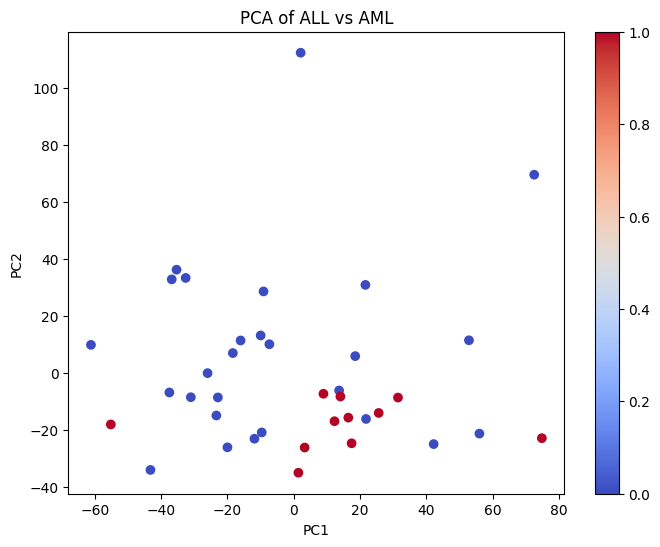

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_train,
    cmap='coolwarm'
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of ALL vs AML')
plt.colorbar()
plt.show()

In [37]:
plt.savefig('pca_plot.png')

<Figure size 640x480 with 0 Axes>

In [38]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=42
)

X_tsne = tsne.fit_transform(X_train)

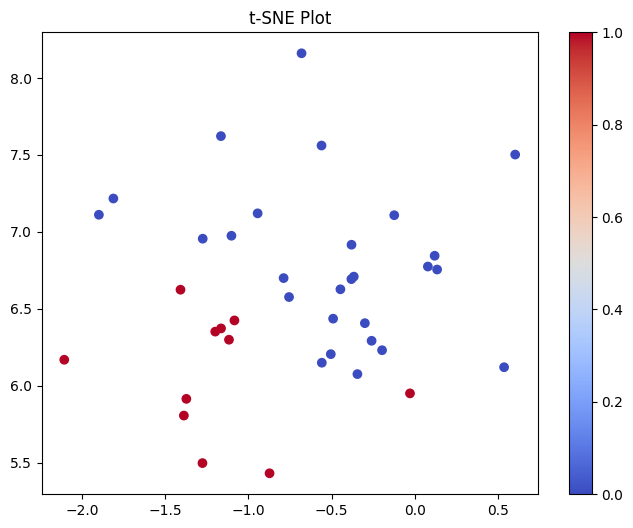

In [39]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=y_train,
    cmap='coolwarm'
)

plt.title('t-SNE Plot')
plt.colorbar()
plt.show()

In [40]:
plt.savefig('tsne_plot.png')

<Figure size 640x480 with 0 Axes>

In [46]:
# The original train DataFrame has 'Gene Accession Number' as a row after transposition,
# and its index does not align with y_train's default integer index.
# train_numeric was created earlier by dropping 'Gene Accession Number' and has index [1, 2, ..., 38].
# y_train has index [0, 1, ..., 37].
# We need to ensure that the index of y_train aligns with train_numeric.

# Create a temporary y_train with patient IDs as index, corresponding to train_numeric's index
y_train_aligned = actual.iloc[:38].set_index('patient')['cancer']

# Convert the index of train_numeric to integer type to match y_train_aligned
# The index of train_numeric are strings '1', '2', ..., '38' from the original column headers.
train_numeric.index = train_numeric.index.astype(int)

# Convert all gene expression columns in train_numeric to numeric type
# This is crucial because they are currently of 'object' dtype (strings) and will cause ttest_ind to fail.
train_numeric = train_numeric.apply(pd.to_numeric, errors='coerce')


# Now use train_numeric and y_train_aligned for boolean indexing
all_group = train_numeric[y_train_aligned == 0]
aml_group = train_numeric[y_train_aligned == 1]

/tmp/ipykernel_598/2970901630.py:20: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  all_group = train_numeric[y_train_aligned == 0]
/tmp/ipykernel_598/2970901630.py:21: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  aml_group = train_numeric[y_train_aligned == 1]


In [44]:
from scipy.stats import ttest_ind

In [45]:
pvalues = []

for gene in train.columns:

    p = ttest_ind(
        all_group[gene],
        aml_group[gene]
    )[1]

    pvalues.append(p)

AttributeError: 'numpy.dtypes.ObjectDType' object has no attribute 'dtype'

In [47]:
pvalues = []

for gene in train_numeric.columns:

    # Ensure both groups are numeric and handle potential NaNs (from 'coerce' in to_numeric)
    group1 = all_group[gene].dropna()
    group2 = aml_group[gene].dropna()

    # Only perform t-test if both groups have enough data points
    if len(group1) > 1 and len(group2) > 1:
        p = ttest_ind(
            group1,
            group2
        )[1]
        pvalues.append(p)
    else:
        pvalues.append(np.nan) # Append NaN if t-test cannot be performed

print(f"Calculated {len(pvalues)} p-values.")

Calculated 7129 p-values.


In [48]:
de_results = pd.DataFrame({
    'Gene':train.columns,
    'P_value':pvalues
})

In [51]:
import numpy as np # Ensure numpy is imported for np.ndarray check

# Ensure all 'P_value' entries are scalar before sorting.
# This handles cases where p-values might be returned as lists or numpy arrays with multiple elements.
def ensure_scalar_pvalue(p_val):
    if isinstance(p_val, (list, np.ndarray)):
        # If it's a list or numpy array, take the first element if it exists.
        if len(p_val) > 0:
            return p_val[0]
        else:
            return np.nan # Handle empty arrays/lists as NaN
    return p_val

de_results['P_value'] = de_results['P_value'].apply(ensure_scalar_pvalue)

# Now, ensure the entire 'P_value' column is of a numeric type, converting non-numeric to NaN
# This helps catch any remaining non-comparable types that might have slipped through
de_results['P_value'] = pd.to_numeric(de_results['P_value'], errors='coerce')

de_results = de_results.sort_values(
    'P_value'
)

In [52]:
de_results.head(20)

,Gene,P_value
3319,Leukotriene C4 synthase (LTC4S) gene,1.382386e-10
4846,Zyxin,2.435528e-10
2019,FAH Fumarylacetoacetate,6.577977e-10
1744,LYN V-yes-1 Yamaguchi sarcoma viral related on...,9.846897e-09
1833,CD33 CD33 antigen (differentiation antigen),1.514532e-08
460,Liver mRNA for interferon-gamma inducing facto...,3.610124e-08
4195,PRG1 Proteoglycan 1; secretory granule,6.156941e-08
3846,GB DEF = Homeodomain protein HoxA9 mRNA,7.157106e-08
2287,DF D component of complement (adipsin),8.917170e-08
1248,INDUCED MYELOID LEUKEMIA CELL DIFFERENTIATION ...,1.740680e-07


In [53]:
de_results.to_csv(
    'differential_expression.csv',
    index=False
)

In [54]:
de_results['minus_log10_p'] = \
    -np.log10(de_results['P_value'])

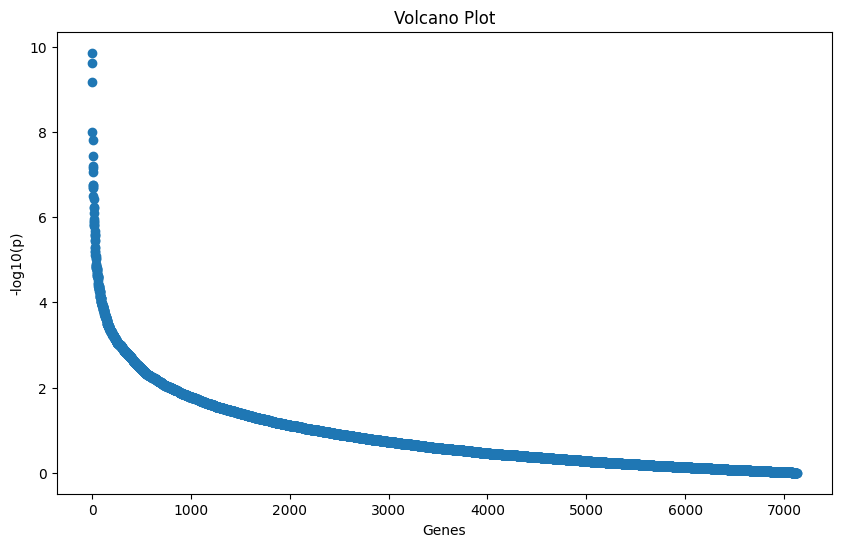

In [55]:
plt.figure(figsize=(10,6))

plt.scatter(
    range(len(de_results)),
    de_results['minus_log10_p']
)

plt.xlabel('Genes')
plt.ylabel('-log10(p)')
plt.title('Volcano Plot')
plt.show()

In [56]:
plt.savefig('volcano_plot.png')

<Figure size 640x480 with 0 Axes>

In [57]:
top50 = de_results.head(50)['Gene']

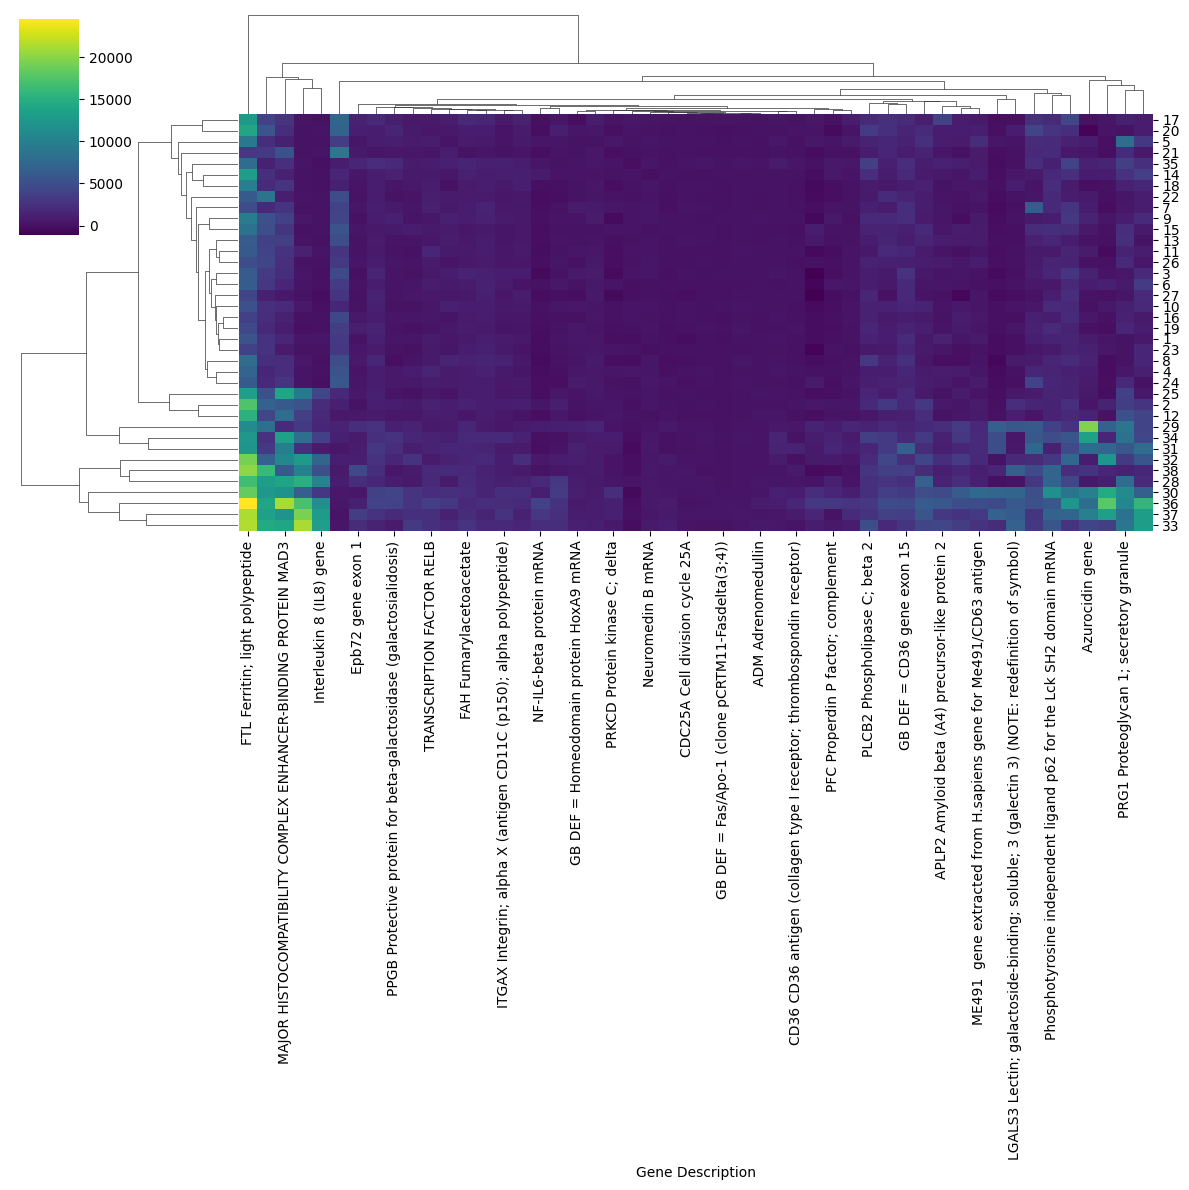

In [59]:
sns.clustermap(
    train_numeric[top50],
    figsize=(12,12),
    cmap='viridis'
)

In [60]:
plt.savefig('heatmap.png')

<Figure size 640x480 with 0 Axes>

In [61]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [62]:
pred_rf = rf.predict(X_test)

In [63]:
from sklearn.metrics import accuracy_score

accuracy_score(
    y_test,
    pred_rf
)

0.6764705882352942

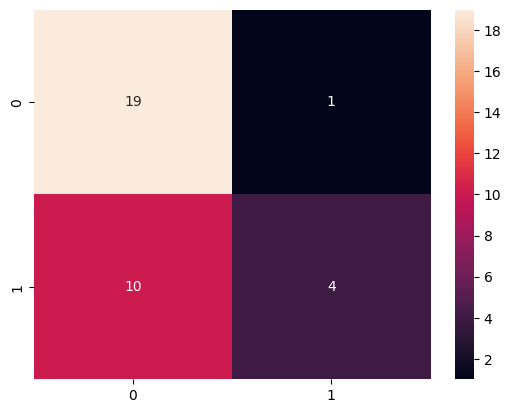

In [64]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    pred_rf
)

sns.heatmap(
    cm,
    annot=True
)
plt.show()

In [65]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.66      0.95      0.78        20
           1       0.80      0.29      0.42        14

    accuracy                           0.68        34
   macro avg       0.73      0.62      0.60        34
weighted avg       0.71      0.68      0.63        34



In [66]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(
    X_train,
    y_train
)

pred_svm = svm.predict(X_test)

accuracy_score(
    y_test,
    pred_svm
)

0.6176470588235294

In [67]:
importance = pd.DataFrame({
    'Gene':train.columns,
    'Importance':rf.feature_importances_
})

In [68]:
importance = importance.sort_values(
    'Importance',
    ascending=False
)

In [69]:
importance.to_csv(
    'feature_importance.csv',
    index=False
)

In [70]:
import os

os.makedirs(
    'results',
    exist_ok=True
)

In [71]:
de_results.to_csv(
    'results/differential_expression.csv',
    index=False
)

importance.to_csv(
    'results/feature_importance.csv',
    index=False
)

In [72]:
from google.colab import files

files.download(
    'results/differential_expression.csv'
)

files.download(
    'results/feature_importance.csv'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>